    # Exploração de dados : Pokemon

Bem-vindo(a) a este projeto de Ciência de Dados focado no universo de Pokémon! Neste notebook, vou explorar, limpar e analisar os dados de diversas gerações de pokemons.

### Objetivos deste Notebook:
* **Limpeza e Tratamento:** Preparar nossa base de dados para a análise, lidando com valores ausentes e dados duplicados.
* **Análise Exploratória de Dados (EDA):** Descobrir padrões e curiosidades.
* **Visualização de Dados:** Criar gráficos para ilustrar diferentes cenários.
* **Modelagem:** Construir um modelo de *Machine Learning* para classificação ou previsão.

In [7]:
# Importação de bibliotecas padrão para a manipulçao de dados, assim como a visualização de informações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pokemons = pd.read_csv('Pokemon.csv')

pokemons.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## 1. Inspeção Inicial da Base de Dados

Verificação da estrutura geral do DataFrame, incluindo os tipos de dados de cada coluna e a presença de valores nulos.

In [8]:
pokemons.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   Total       800 non-null    int64
 5   HP          800 non-null    int64
 6   Attack      800 non-null    int64
 7   Defense     800 non-null    int64
 8   Sp. Atk     800 non-null    int64
 9   Sp. Def     800 non-null    int64
 10  Speed       800 non-null    int64
 11  Generation  800 non-null    int64
 12  Legendary   800 non-null    bool 
dtypes: bool(1), int64(9), str(3)
memory usage: 75.9 KB


## 2. Estatísticas Descritivas

Analisaremos as principais medidas estatísticas (média, desvio padrão, quartis, mínimo e máximo) dos atributos de combate e gerações.

In [9]:
pokemons.drop('#', axis = 1).describe().T

,count,mean,std,min,25%,50%,75%,max
Total,800.0,435.10250,119.963040,180.0,330.00,450.0,515.0,780.0
HP,800.0,69.25875,25.534669,1.0,50.00,65.0,80.0,255.0
Attack,800.0,79.00125,32.457366,5.0,55.00,75.0,100.0,190.0
Defense,800.0,73.84250,31.183501,5.0,50.00,70.0,90.0,230.0
Sp. Atk,800.0,72.82000,32.722294,10.0,49.75,65.0,95.0,194.0
Sp. Def,800.0,71.90250,27.828916,20.0,50.00,70.0,90.0,230.0
Speed,800.0,68.27750,29.060474,5.0,45.00,65.0,90.0,180.0
Generation,800.0,3.32375,1.661290,1.0,2.00,3.0,5.0,6.0


## 3. Limpeza e Tratamento de Dados

Nesta etapa, verificamos a existência de linhas duplicadas e valores ausentes (`NaN`) nas colunas.

In [10]:
pokemons.duplicated().sum()

np.int64(0)

In [11]:
pokemons.isnull().sum()

#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

Como podemos observar, a coluna `Type 2` possui diversos valores ausentes, o que é perfeitamente normal, pois muitos Pokémon possuem apenas um único tipo. Vamos substituir esses valores nulos por uma string vazia para mantermos a integridade dos dados.

In [12]:
pokemons.fillna({'Type 2' : ''}, inplace=True) # Subsitui valores não definidos por uma string vazia.

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [13]:
pokemons.isnull().sum()

#             0
Name          0
Type 1        0
Type 2        0
Total         0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64

## 4. Análise Exploratória de Dados (EDA) e Visualizações

### 4.1. Distribuição dos Tipos Primários (`Type 1`)
Vamos criar um gráfico de barras para visualizar a contagem de Pokémon por cada tipo primário, utilizando uma paleta de cores temática inspirada nos jogos oficiais.

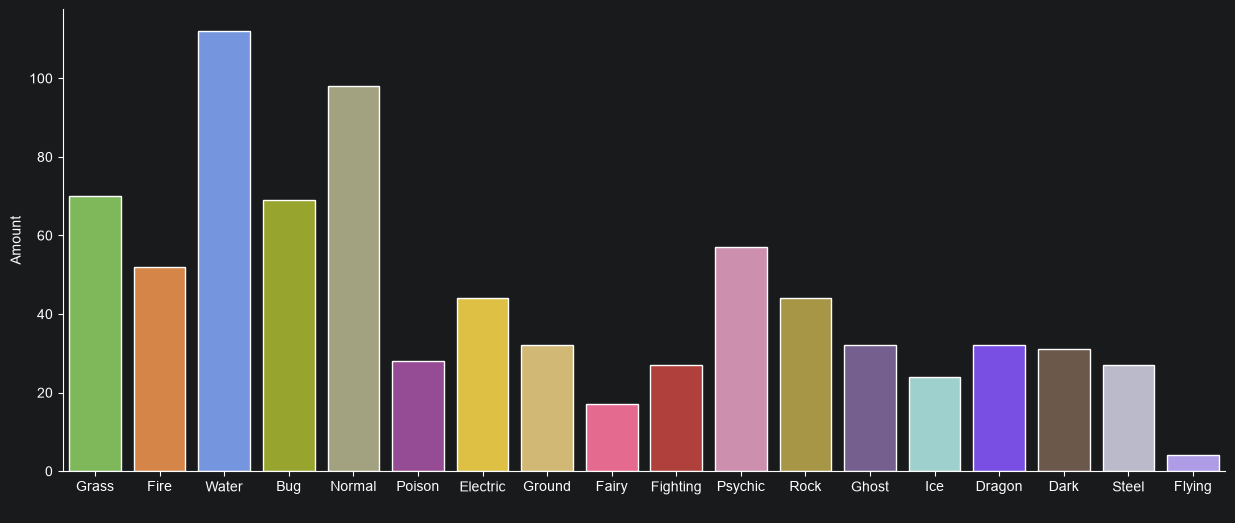

In [14]:
# Plota em um gráfico de barras simples, os tipos e quantidades de pokemons presentes no banco de dados
plt.figure(figsize = (15,6))
pokemon_colors = {
    "Normal": "#A8A77A",
    "Fire": "#EE8130",
    "Water": "#6390F0",
    "Electric": "#F7D02C",
    "Grass": "#7AC74C",
    "Ice": "#96D9D6",
    "Fighting": "#C22E28",
    "Poison": "#A33EA1",
    "Ground": "#E2BF65",
    "Flying": "#A98FF3",
    "Psychic": "#D685AD",
    "Bug": "#A6B91A",
    "Rock": "#B6A136",
    "Ghost": "#735797",
    "Dragon": "#6F35FC",
    "Dark": "#705746",
    "Steel": "#B7B7CE",
    "Fairy": "#F95587",
}

plt.xlabel(' ')
plt.ylabel('Amount')
sns.set_style("white")
sns.countplot(data = pokemons, x = 'Type 1', hue = 'Type 1' ,palette = pokemon_colors, legend = False)
sns.despine()


### 4.2. Consulta Específica: Pokémon Psíquicos Lendários
Vamos filtrar o DataFrame para identificar quais Pokémon possuem o tipo primário **Psychic** e também o status de **Legendary**.

In [15]:
pokemons.loc[(pokemons['Type 1'] == 'Psychic') & (pokemons['Legendary']), ['Name','Generation']] # Pokemons lendários e psiquicos

,Name,Generation
162,Mewtwo,1
163,MewtwoMega Mewtwo X,1
164,MewtwoMega Mewtwo Y,1
269,Lugia,2
428,DeoxysNormal Forme,3
429,DeoxysAttack Forme,3
430,DeoxysDefense Forme,3
431,DeoxysSpeed Forme,3
537,Uxie,4
538,Mesprit,4


### 4.3. Comparação de Atributos: Lendários vs. Não Lendários
Utilizaremos um *boxplot* para comparar a distribuição dos atributos totais (`Total`) entre Pokémon lendários e comuns.

[Text(0, 0, ''), Text(1, 0, '')]

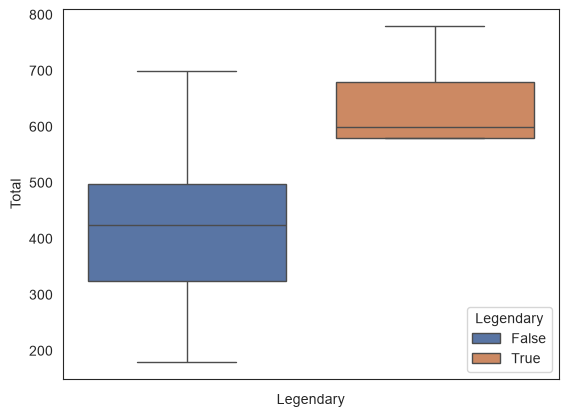

In [16]:
# Distribuição de atributos totais, baseando-se se o pokemon é lendário ou não
ax = sns.boxplot(data=pokemons, x="Legendary", y="Total", hue="Legendary", palette='deep')

ax.set_xticklabels([])

### 4.4. Matriz de Correlação entre Atributos Numéricos
Para entender como os status (HP, Ataque, Defesa, Velocidade) se relacionam, mapeamos os tipos categóricos para numéricos e geramos uma matriz de correlação com mapa de calor.

In [17]:
# Construindo uma coluna contendo numeros no lugar de tipos de pokemon, para avaliar a variável tipo.
def numericalTypes ():
    types = dict()
    i = 0
    for type in pokemons['Type 1'].unique():
        types[type] = i
        i += 1
    return types

pokemons['NumericalTypes'] = pokemons['Type 1'].map(numericalTypes())


<Axes: >

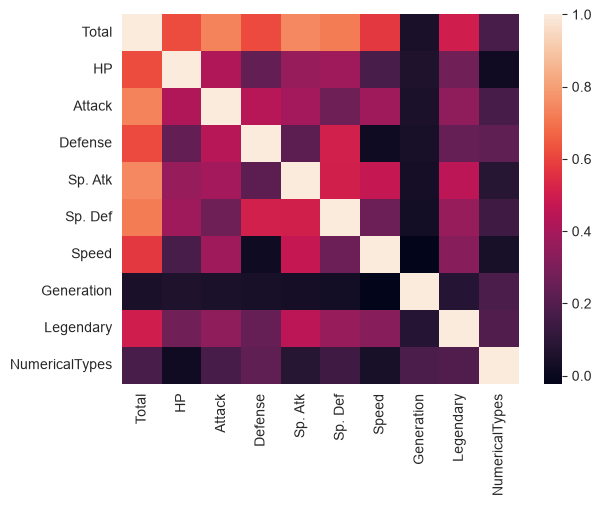

In [18]:
# Heatmap contendo a correlação entre variáveis numéricas
numericalColumns = pokemons.iloc[:, 4:]
sns.heatmap(data = numericalColumns.corr())

### 4.5. Pair Plot de alguns atributos numéricos
Tabelas de distribuição e gráficos de dispersão de variáveis numéricas: 'Total', 'HP', 'Attack','Defense','Speed' e 'NumericalTypes'


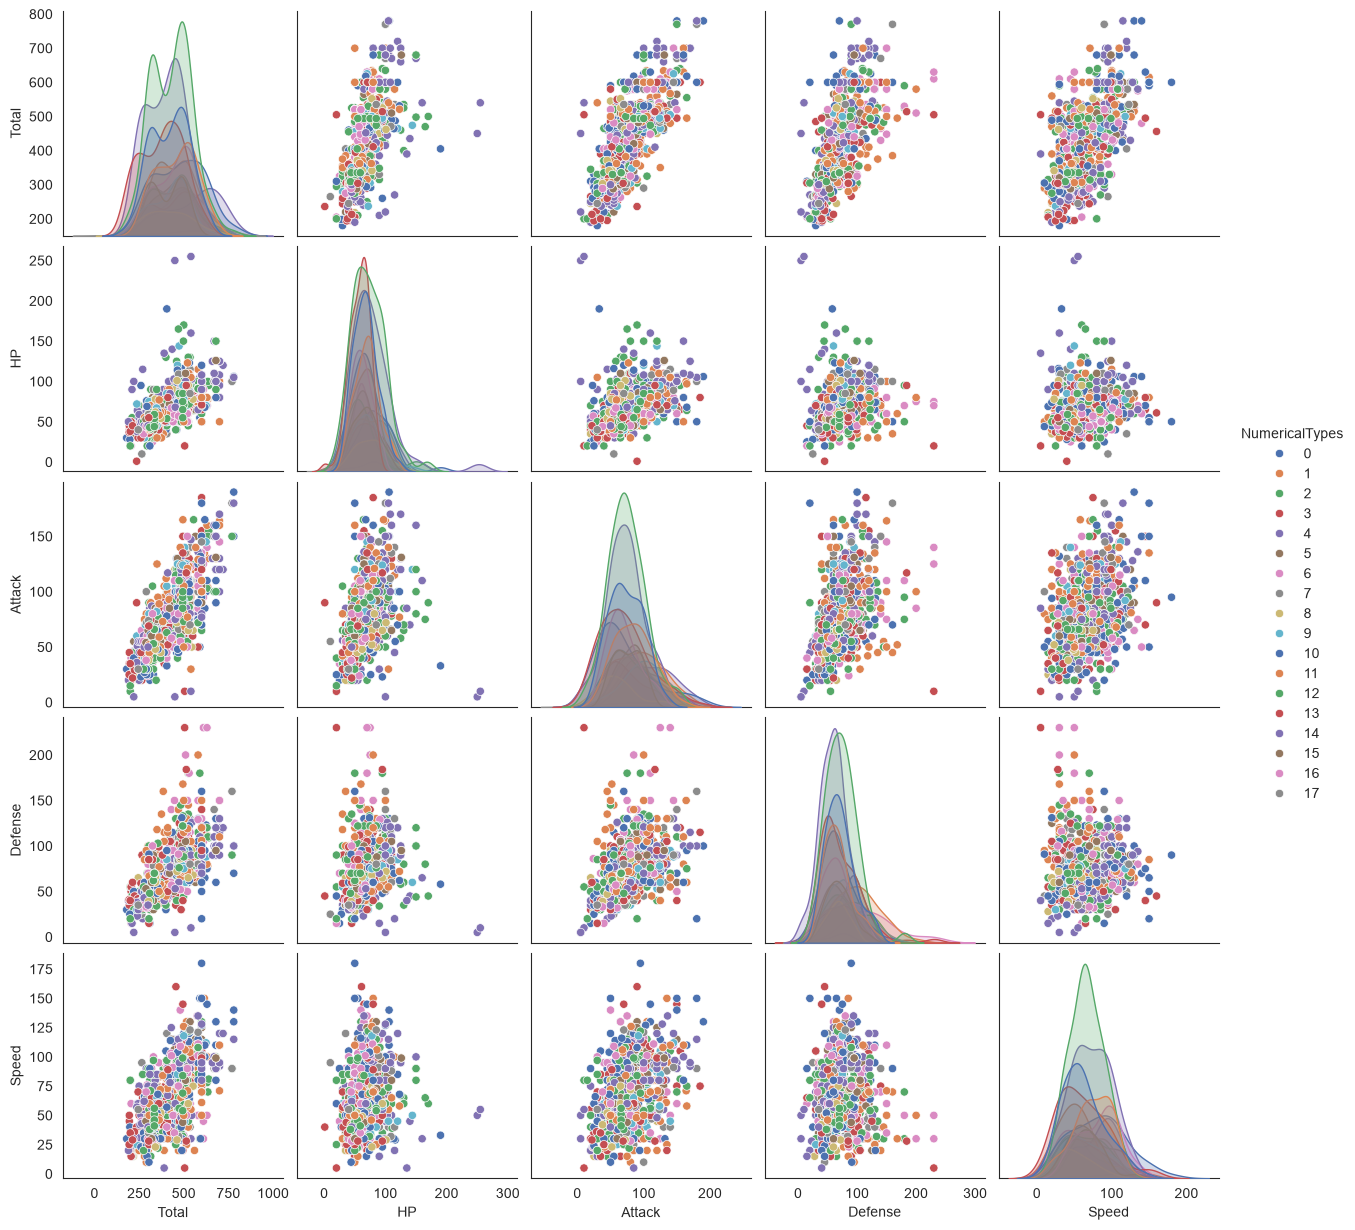

In [19]:
g = sns.pairplot(data = numericalColumns[['Total','HP','Attack','Defense','Speed','NumericalTypes']], palette = 'deep', hue = 'NumericalTypes')

## Modelagem de Machine Learning: Classificação

### 5.1. Regressão Logística

Iniciamos nossos modelos preditivos utilizando a **Regressão Logística** para prever se um Pokémon é ou não lendário (`Legendary`), dividindo os dados em conjuntos de treino e teste.


In [20]:
# Importação de bibliotecas para aprendizagem de máquina ('Regressão logistica' e 'métricas de modelo')
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [21]:
X = numericalColumns.drop('Legendary', axis = 1)
Y = numericalColumns['Legendary']

In [22]:
x_train, x_test, y_train, y_test = train_test_split( X, Y, test_size = 0.25) #Divisão das variáveis para treinamento do modelo e outras para teste.

In [23]:
logmodel = LogisticRegression(max_iter = 1000) #Utilização de modelo simples de classificação
logmodel.fit(x_train, y_train) #Treinamento

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### 5.2. Avaliação do Modelo de Regressão Logística

Analisamos a matriz de confusão e o relatório de classificação (*classification report*) para verificar a precisão, revocação (*recall*) e o desempenho geral do modelo nas classes.

In [24]:
confusion_matrix(y_test, logmodel.predict(x_test))

array([[170,   7],
       [ 11,  12]])

In [25]:
print(classification_report(y_test, logmodel.predict(x_test)))

              precision    recall  f1-score   support

       False       0.94      0.96      0.95       177
        True       0.63      0.52      0.57        23

    accuracy                           0.91       200
   macro avg       0.79      0.74      0.76       200
weighted avg       0.90      0.91      0.91       200



### 5.3. k nearest neighbor

Outro modelo preditivo para prever se um Pokémon é ou não lendário (`Legendary`), dividindo os dados em conjuntos de treino e teste.

In [26]:
# Importação de bibliotecas para aprendizagem de máquina e para aprendizagem balanceada ( 'KNN' e 'SMOTE')
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

### 5.3. Tratamento de Desbalanceamento com SMOTE e Padronização\n",
Como o dataset possui poucos Pokémon lendários em comparação aos comuns, aplicamos a técnica **SMOTE** (*Synthetic Minority Over-sampling Technique*) combinada com a padronização das features via `StandardScaler` para equilibrar o treinamento.

In [27]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=101)


scaler = StandardScaler() #padronizar as features
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

smote = SMOTE(random_state=101) #Lidar com classes desbalanceadas

x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

### 5.4. Otimização do K-NN (K-Nearest Neighbors)\n",
Testamos múltiplos valores para o parâmetro $K$ (número de vizinhos) para identificar qual valor minimiza a taxa de erros nos testes."


In [28]:
error_rate = [] #Encontrar o local onde K gera o menor erros nos testes
for i in range (1,40):
    model = KNeighborsClassifier(n_neighbors = i)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    erro = np.mean(y_pred != y_test)
    error_rate.append(erro)

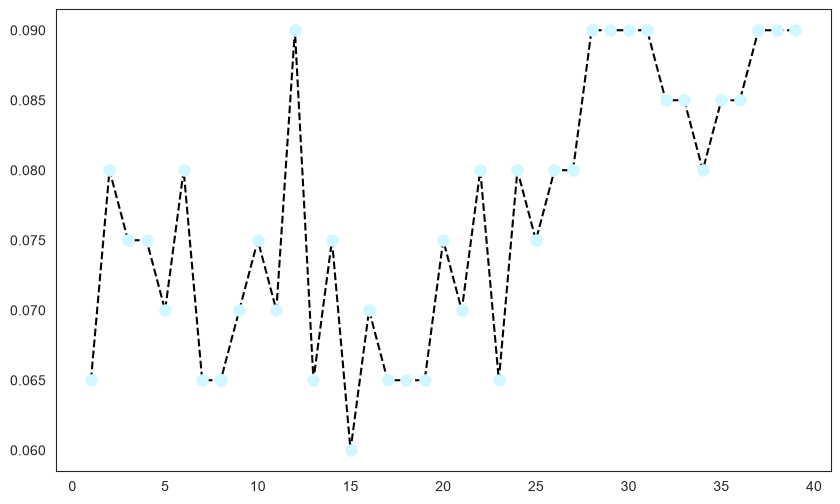

In [29]:
plt.figure(figsize=(10, 6))

#Plotagem dos erros para fácil visualização
plt.plot(range(1, 40), error_rate,
         color='black',
         linestyle='dashed',
         marker='o',
         markerfacecolor = '#D2F7FF',
         markeredgecolor = '#D2F7FF',
        markersize=8)

### 5.5. Treinamento e Avaliação do K-NN com $K = 15$
Treinamos o classificador K-NN utilizando os dados balanceados pelo SMOTE com $K=15$ e avaliamos sua performance preditiva.

In [30]:
k = 15
# Utilização do modelo de aprendizagem 'KNN' para a previsão da classificação
model = KNeighborsClassifier(n_neighbors= k )
model.fit(x_train_smote, y_train_smote)
y_pred = model.predict(x_test_scaled)

In [31]:
confusion_matrix(y_test, y_pred)

array([[159,  21],
       [  2,  18]])

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.99      0.88      0.93       180
        True       0.46      0.90      0.61        20

    accuracy                           0.89       200
   macro avg       0.72      0.89      0.77       200
weighted avg       0.93      0.89      0.90       200



## 6. Modelagem de Machine Learning: Regressão Linear,

Além da classificação, aplicamos um modelo de **Regressão Linear** para prever o valor de `HP` de um Pokémon com base em seus atributos de `Attack`, `Defense` e `Speed`.

In [33]:
from sklearn.linear_model import LinearRegression #Importação para a regressão Linear

In [34]:
X = numericalColumns[['Attack','Defense','Speed']]
Y = numericalColumns['HP']

In [35]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [36]:
lm = LinearRegression()
lm.fit(x_train, y_train) # Treinamento do modelo

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.29,0.06,0.04]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Attack','Defense','Speed']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,38.69
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


### 6.1. Métricas de Avaliação da Regressão
Calculamos o Erro Absoluto Médio (MAE), Erro Quadrático Médio (MSE) e a Raiz do Erro Quadrático Médio (RMSE) para mensurar a precisão das previsões de HP.

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error
mae = mean_absolute_error(y_test, lm.predict(x_test))
mse = mean_squared_error(y_test, lm.predict(x_test))
rmse = root_mean_squared_error(y_test, lm.predict(x_test))

# Métricas para a avaliação do modelo, demonstrando o variabilidade alta dos dados e dificuldade de previsão devido à presença de valores descrepantes

print(f'Mean absolute error: {mae:.2f} \nMean squared error: {mse:.2f} \nRoot mean squared error: {rmse:.2f}')

Mean absolute error: 15.71 
Mean squared error: 466.89 
Root mean squared error: 21.61
